In [1]:
!pip install geopandas rasterio xlrd 

import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling 
from rasterio.mask import mask
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
from scipy.stats import skew, kurtosis
import seaborn as sns
from plot_functions import plot_boxplots, plot_distributions

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### 👀 Visualisation

Original shape: 33600 x 86400
Downsampled shape: (3360, 8640)


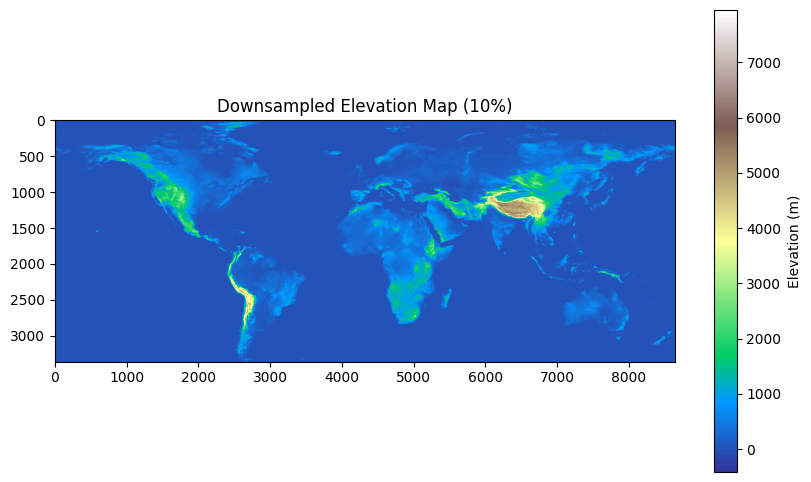

In [2]:

# Path to the folder (the folder itself is the "dataset")
raster_file = "../datasets/be15_grd/be15_grd/w001000.adf"


with rasterio.open(raster_file) as src:
    print("Original shape:", src.height, "x", src.width)
    scale = 0.1
    new_height = int(src.height * scale)
    new_width = int(src.width * scale)
    elevation = src.read(
        1,
        out_shape=(1, new_height, new_width),
        resampling=Resampling.average
    )
    transform = src.transform * src.transform.scale(
        (src.width / new_width),
        (src.height / new_height)
    )

print("Downsampled shape:", elevation.shape)
plt.figure(figsize=(10, 6))
plt.imshow(elevation, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Downsampled Elevation Map (10%)")
plt.show()



#### ⛓️‍💥Clip Algeria & tunisia

{'driver': 'AIG', 'dtype': 'int16', 'nodata': -32768.0, 'width': 86400, 'height': 33600, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.004166666666666664, 0.0, -180.00013888888893,
       0.0, -0.004166666666666664, 83.999861111111)}


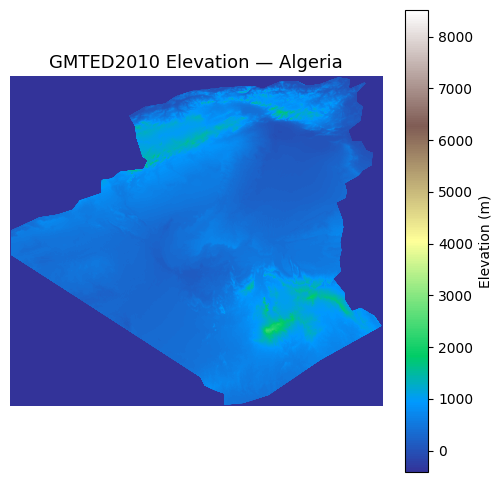

In [3]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# -----------------------------
# Paths
# -----------------------------
shapefile_path = "../datasets/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
raster_path = "../datasets/be15_grd/be15_grd/w001000.adf"

# -----------------------------
# Load country shapes
# -----------------------------
world = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
world["ADMIN"] = world["ADMIN"].str.strip().str.lower()

algeria = world[world["ADMIN"].isin(["algeria", "tunisia"])]

if algeria.empty :
    raise ValueError("Could not find Algeria or Tunisia in the shapefile.")

# -----------------------------
# Clip raster function
# -----------------------------
def clip_raster(raster_path, country_gdf):
    with rasterio.open(raster_path) as src:
        # Replace deprecated unary_union with union_all()
        country_geom = [country_gdf.geometry.union_all()]  # Fixed line
        clipped_image, clipped_transform = mask(src, country_geom, crop=True)
        clipped_meta = src.meta.copy()
        clipped_meta.update({
            "height": clipped_image.shape[1],
            "width": clipped_image.shape[2],
            "transform": clipped_transform
        })
    return clipped_image[0], clipped_meta
# -----------------------------
# Memory-safe clipping
# -----------------------------
algeria_clip, _ = clip_raster(raster_path, algeria)

# -----------------------------
# Use original raster's global min/max for consistent colors
# -----------------------------
with rasterio.open(raster_path) as src:
    # Read in a downsampled version to get min/max without MemoryError
    print(src.meta) 
    factor = 10  # downsample factor for stats
    out_shape = (1, src.height // factor, src.width // factor)
    data_small = src.read(1, out_shape=out_shape, masked=True)
    global_min = data_small.min()
    global_max = data_small.max()
    nodata = src.nodata



norm = Normalize(vmin=global_min, vmax=global_max)

# -----------------------------
# Plot function
# -----------------------------
def plot_raster(data, title):
    plt.figure(figsize=(6,6))
    plt.imshow(data, cmap= "terrain" , norm=norm)
    plt.title(title, fontsize=13)
    plt.colorbar(label="Elevation (m)")
    plt.axis("off")
    plt.show()

# -----------------------------
# Plot clipped maps
# -----------------------------
plot_raster(algeria_clip, "GMTED2010 Elevation — Algeria")



## 🔎 Exploratary Data Analysis

In [4]:

print(data_small.shape)     # dimensions
# Aplatir en 1D pour les stats
values = data_small.flatten()
values2 = values[values != nodata]  # enlever les valeurs manquantes

(3360, 8640)


In [5]:
missing_count = np.sum(data_small == nodata)
print("Valeurs manquantes :", missing_count)

Valeurs manquantes : 0


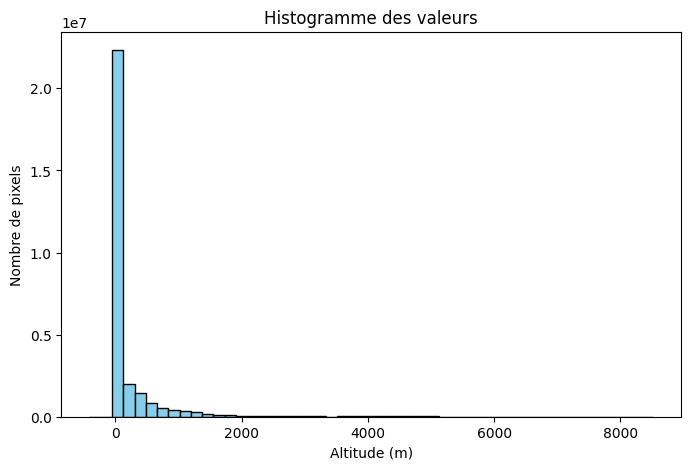

In [6]:
plt.figure(figsize=(8,5))
plt.hist(values, bins=50, color='skyblue', edgecolor='black')
plt.title("Histogramme des valeurs")
plt.xlabel("Altitude (m)")
plt.ylabel("Nombre de pixels")
plt.show()


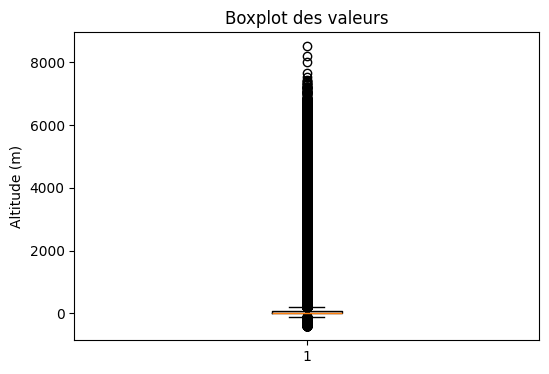

In [7]:
plt.figure(figsize=(6,4))
plt.boxplot(values, vert=True)
plt.title("Boxplot des valeurs")
plt.ylabel("Altitude (m)")
plt.show()

In [8]:
Q1 = np.percentile(values, 25)
Q3 = np.percentile(values, 75)
IQR = Q3 - Q1

outliers = values[(values < Q1 - 1.5*IQR) | (values > Q3 + 1.5*IQR)]
print("Nombre d'outliers :", len(outliers))
print("Exemples :", outliers[:10])


C:\Users\MELISSA\AppData\Roaming\Python\Python310\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Nombre d'outliers : 5632190
Exemples : [302 245 320 311 333 339 318 257 245 283]


In [9]:
# -----------------------------
# Exploratory Data Analysis
# -----------------------------
import numpy as np
from scipy import stats
import seaborn as sns

def analyze_elevation_data(data, region_name, nodata_value):
    """Comprehensive analysis of elevation data"""
    
    # Mask NoData values
    masked_data = np.ma.masked_equal(data, nodata_value)
    valid_data = masked_data.compressed()
    
    if len(valid_data) == 0:
        print(f"No valid data found for {region_name}")
        return
    
    print(f"\n{'='*50}")
    print(f"ELEVATION ANALYSIS: {region_name.upper()}")
    print(f"{'='*50}")
    
    # Basic statistics
    print(f"Valid pixels: {len(valid_data):,}")
    print(f"Data coverage: {(len(valid_data)/data.size*100):.1f}%")
    print(f"Min elevation: {valid_data.min():.1f} m")
    print(f"Max elevation: {valid_data.max():.1f} m")
    print(f"Mean elevation: {valid_data.mean():.1f} m")
    print(f"Median elevation: {np.median(valid_data):.1f} m")
    print(f"Standard deviation: {valid_data.std():.1f} m")
    
    # Percentiles
    percentiles = [0, 25, 50, 75, 95, 99, 100]
    percentile_values = np.percentile(valid_data, percentiles)
    print("\nElevation percentiles (m):")
    for p, val in zip(percentiles, percentile_values):
        print(f"  {p}th: {val:.1f}")
    
    # Distribution characteristics
    print(f"\nDistribution shape:")
    print(f"  Skewness: {stats.skew(valid_data):.3f}")
    print(f"  Kurtosis: {stats.kurtosis(valid_data):.3f}")
    
    # Elevation zones analysis
    elevation_zones = {
        'Lowlands (<200m)': (valid_data < 200).sum(),
        'Midlands (200-800m)': ((valid_data >= 200) & (valid_data < 800)).sum(),
        'Highlands (800-1500m)': ((valid_data >= 800) & (valid_data < 1500)).sum(),
        'Mountains (≥1500m)': (valid_data >= 1500).sum()
    }
    
    print(f"\nElevation zones (pixel count):")
    for zone, count in elevation_zones.items():
        percentage = (count / len(valid_data)) * 100
        print(f"  {zone}: {count:,} ({percentage:.1f}%)")

# Analyze Algeria/Tunisia data
analyze_elevation_data(algeria_clip, "Algeria and Tunisia", nodata)


ELEVATION ANALYSIS: ALGERIA AND TUNISIA
Valid pixels: 13,183,993
Data coverage: 60.5%
Min elevation: -872.0 m
Max elevation: 2877.0 m
Mean elevation: 536.4 m
Median elevation: 463.0 m
Standard deviation: 325.5 m

Elevation percentiles (m):
  0th: -872.0
  25th: 310.0
  50th: 463.0
  75th: 697.0
  95th: 1177.0
  99th: 1483.0
  100th: 2877.0

Distribution shape:
  Skewness: 1.046
  Kurtosis: 1.223

Elevation zones (pixel count):
  Lowlands (<200m): 1,393,825 (10.6%)
  Midlands (200-800m): 9,277,396 (70.4%)
  Highlands (800-1500m): 2,390,669 (18.1%)
  Mountains (≥1500m): 122,103 (0.9%)


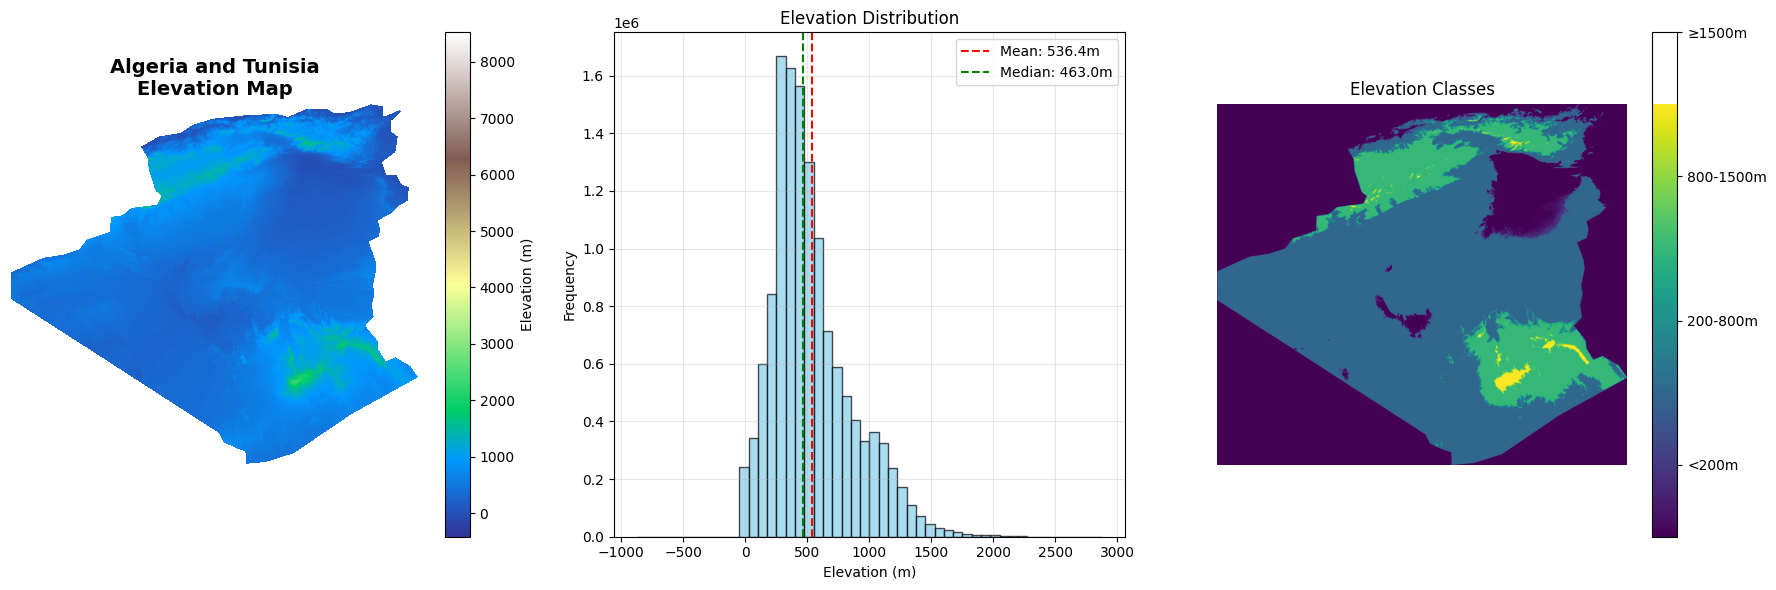

In [10]:
def plot_enhanced_raster_simple(data, title, nodata_value):
    
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Mask NoData
    masked_data = np.ma.masked_equal(data, nodata_value)
    valid_data = masked_data.compressed()
    
    # Main elevation map
    im1 = axes[0].imshow(masked_data, cmap="terrain", norm=norm)
    axes[0].set_title(f"{title}\nElevation Map", fontsize=14, weight='bold')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label="Elevation (m)")
    
    # Histogram
    axes[1].hist(valid_data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1].axvline(valid_data.mean(), color='red', linestyle='--', 
                   label=f'Mean: {valid_data.mean():.1f}m')
    axes[1].axvline(np.median(valid_data), color='green', linestyle='--', 
                   label=f'Median: {np.median(valid_data):.1f}m')
    axes[1].set_xlabel('Elevation (m)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Elevation Distribution')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Simple elevation classification
    # Use a predefined colormap directly
    elevation_classes = np.digitize(masked_data, [200, 800, 1500])
    im3 = axes[2].imshow(elevation_classes, cmap='viridis')
    axes[2].set_title('Elevation Classes')
    axes[2].axis('off')
    cbar = plt.colorbar(im3, ax=axes[2])
    cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
    cbar.set_ticklabels(['<200m', '200-800m', '800-1500m', '≥1500m'])
    
    plt.tight_layout()
    plt.show()
    
# Plot enhanced raster for Algeria/Tunisia
plot_enhanced_raster_simple(algeria_clip, "Algeria and Tunisia", nodata)

## 📝 Prétraitement et Outliers


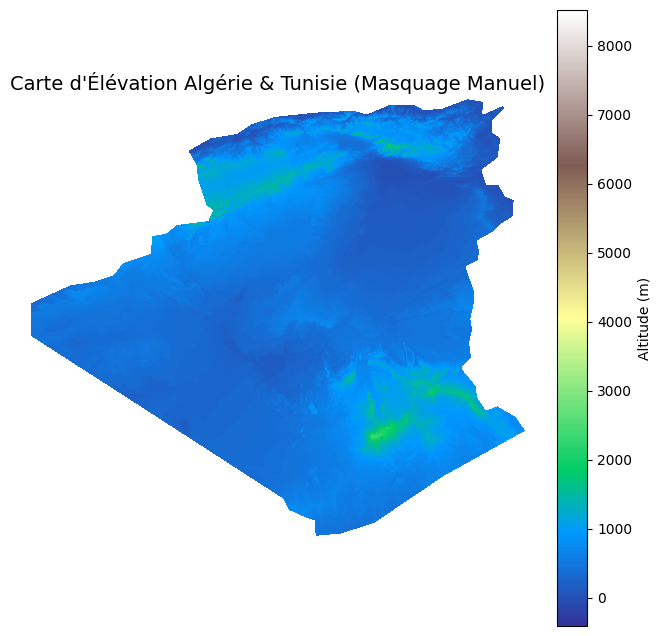

In [11]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np 

# -----------------------------
# Paths (Adapt these to your local file structure)
# -----------------------------
shapefile_path = "../datasets/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
raster_path = "../datasets/be15_grd/be15_grd/w001000.adf"

# --- PARAMÈTRES DE PRÉTRAITEMENT ---
# Nous utilisons np.nan pour marquer les pixels exclus des calculs.
NEW_NODATA_VALUE = np.nan 

# -----------------------------
# Load country shapes
# -----------------------------
world = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
world["ADMIN"] = world["ADMIN"].str.strip().str.lower()
algeria_tunisia = world[world["ADMIN"].isin(["algeria", "tunisia"])]

if algeria_tunisia.empty:
    raise ValueError("Could not find Algeria or Tunisia in the shapefile.")

# -----------------------------
# Clip raster function (CORRIGÉE : Utilisation manuelle du NoData)
# -----------------------------
def clip_raster(raster_path, country_gdf):
    """Découpe le raster et retourne le tableau des données et le NoData source."""
    with rasterio.open(raster_path) as src:
        # Lire le NoData du fichier source
        nodata_source = src.nodata
        
        country_geom = [country_gdf.geometry.union_all()]
        # Utiliser nodata=nodata_source (même si c'est la valeur par défaut)
        # N'incluez PAS l'argument 'masked'
        clipped_image, clipped_transform = mask(
            src, country_geom, crop=True, nodata=nodata_source
        )
        
        clipped_meta = src.meta.copy()
        clipped_meta.update({
            "height": clipped_image.shape[1],
            "width": clipped_image.shape[2],
            "transform": clipped_transform
        })
    # Nous retournons la première bande et la valeur NoData
    return clipped_image[0], clipped_meta, nodata_source 

# -----------------------------
# 1. Découpage (Clipping)
# -----------------------------
algeria_clip, _, nodata_value = clip_raster(raster_path, algeria_tunisia)

# -----------------------------
# 2. Prétraitement (Masquage manuel des zones de NoData)
# -----------------------------
# Créer une copie en float32 pour l'analyse
algeria_clip_processed = algeria_clip.astype(np.float32).copy()

# A. Masquage des zones extérieures au polygone (où mask() a placé le nodata_value)
# Cela corrige le "vide" indésirable
if nodata_value is not None:
    algeria_clip_processed[algeria_clip_processed == nodata_value] = NEW_NODATA_VALUE # np.nan

# B. Masquage des Artefacts (Altitudes > 3000 m)
# Optionnel mais recommandé pour l'intégrité des données
SEUIL_MAX = 3000.0
algeria_clip_processed[algeria_clip_processed > SEUIL_MAX] = NEW_NODATA_VALUE # np.nan

# -----------------------------
# Use original raster's global min/max for consistent colors
# -----------------------------
with rasterio.open(raster_path) as src:
    # Read in a downsampled version to get min/max without MemoryError
    factor = 10  
    out_shape = (1, src.height // factor, src.width // factor)
    data_small = src.read(1, out_shape=out_shape, masked=True)
    global_min = data_small.min()
    global_max = data_small.max() # Utlisez le vrai max ou 3000.0 si le max est un artefact
    
norm = Normalize(vmin=global_min, vmax=global_max)

# -----------------------------
# Plot function
# -----------------------------
def plot_raster(data, title, norm):
    """Affiche le raster. Utilise la fonction set_bad pour gérer les NaN."""
    plt.figure(figsize=(8,8))
    
    # Créer une colormap personnalisée pour gérer les NaN (le NoData)
    cmap = plt.get_cmap("terrain").copy()
    # Définir la couleur pour les valeurs "mauvaises" (bad values = NaN) à blanc ou transparent
    cmap.set_bad('white', alpha=0) 
    
    # Utilisez la carte de couleurs ajustée et le tableau où les zones extérieures sont np.nan
    plt.imshow(data, cmap=cmap, norm=norm)
    plt.title(title, fontsize=14)
    plt.colorbar(label="Altitude (m)")
    plt.axis("off")
    plt.show()

# -----------------------------
# Plot clipped maps (Utilisation du tableau prétraité)
# -----------------------------
plot_raster(
    algeria_clip_processed, 
    "Carte d'Élévation Algérie & Tunisie (Masquage Manuel)",
    norm
)


#### Prétraitement
- **Découpage** : Raster limité à l'Algérie et la Tunisie (`rasterio.mask`), valeurs `nodata` remplacées par `np.nan`.  
- **Filtrage des artefacts** : Élévations > 3000 m remplacées par `np.nan` pour éliminer les erreurs (Mont Tahat conservé ~2900 m).

#### Outliers
- **Hautes altitudes** : Points jusqu'à ~2900 m → vraies montagnes (Atlas, Hoggar), conservés.  
- **Basses altitudes** : Points < 0 → bathymétrie et chotts, conservés pour afficher l'eau.

**Conclusion** : Les outliers restants reflètent fidèlement le relief réel et ne sont pas des erreurs.



✨ ANALYSE STATISTIQUE APRÈS PRÉTRAITEMENT ✨
Nombre total de pixels valides: 13183993
Altitude Minimale (m): -872.0
Altitude Maximale (m): 2877.0
Altitude Moyenne (m): 536.4
Altitude Médiane (m): 463.0
Écart-type (m): 325.5


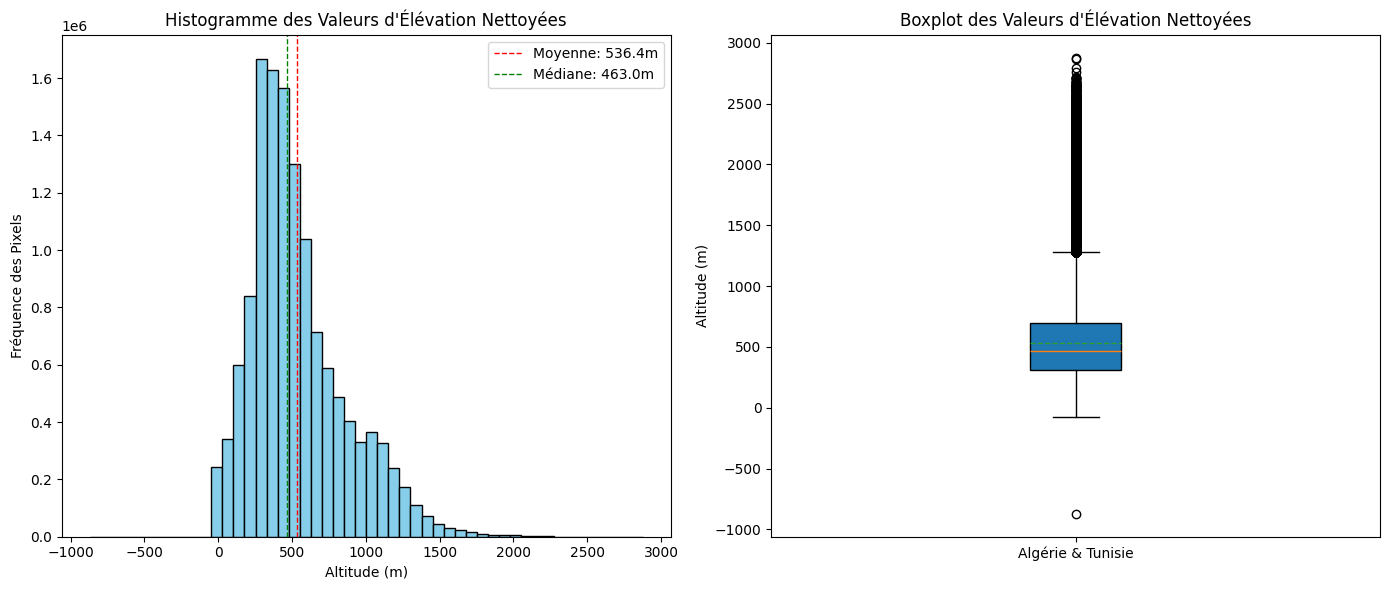

In [12]:
# --- 3. ANALYSE DES OUTLIERS ET DES STATISTIQUES ---

# 1. Calcul des Statistiques
# Utiliser les fonctions nan* de NumPy pour ignorer les np.nan (le NoData)
valid_data = algeria_clip_processed[~np.isnan(algeria_clip_processed)]

if valid_data.size > 0:
    print("\n" + "="*50)
    print("✨ ANALYSE STATISTIQUE APRÈS PRÉTRAITEMENT ✨")
    print("="*50)
    print(f"Nombre total de pixels valides: {valid_data.size}")
    print(f"Altitude Minimale (m): {np.min(valid_data):.1f}")
    print(f"Altitude Maximale (m): {np.max(valid_data):.1f}")
    print(f"Altitude Moyenne (m): {np.mean(valid_data):.1f}")
    print(f"Altitude Médiane (m): {np.median(valid_data):.1f}")
    print(f"Écart-type (m): {np.std(valid_data):.1f}")
    print("="*50)
else:
    print("\nAvertissement : Aucun pixel d'élévation valide trouvé pour l'analyse.")


# 2. Visualisation (Histogramme et Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A. Histogramme des valeurs
# Flatten le tableau 2D et ignore les NaNs
axes[0].hist(
    valid_data, 
    bins=50, 
    edgecolor='black', 
    color='skyblue'
)
axes[0].axvline(np.mean(valid_data), color='red', linestyle='dashed', linewidth=1, label=f'Moyenne: {np.mean(valid_data):.1f}m')
axes[0].axvline(np.median(valid_data), color='green', linestyle='dashed', linewidth=1, label=f'Médiane: {np.median(valid_data):.1f}m')
axes[0].set_title("Histogramme des Valeurs d'Élévation Nettoyées")
axes[0].set_xlabel("Altitude (m)")
axes[0].set_ylabel("Fréquence des Pixels")
axes[0].legend()

# B. Boxplot pour l'identification des Outliers
axes[1].boxplot(
    valid_data, 
    vert=True, 
    patch_artist=True, 
    meanline=True, 
    showmeans=True
)
axes[1].set_title("Boxplot des Valeurs d'Élévation Nettoyées")
axes[1].set_ylabel("Altitude (m)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Algérie & Tunisie'])

plt.tight_layout()
plt.show()


Tentative de sauvegarde du raster prétraité...
✅ Raster prétraité sauvegardé sous **../cleaned_datasets/algeria_tunisia_clip_processed.tif**


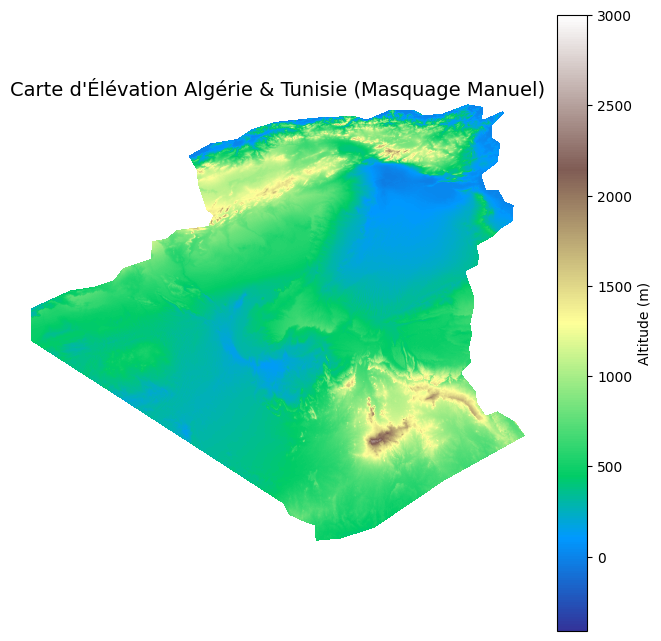

In [13]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask, raster_geometry_mask
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np 

# -----------------------------
# Paths (Adapt these to your local file structure)
# -----------------------------
shapefile_path = "../datasets/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
raster_path = "../datasets/be15_grd/be15_grd/w001000.adf"
output_raster_path = "../cleaned_datasets/algeria_tunisia_clip_processed.tif" # <--- Ajout du chemin de sortie

# --- PARAMÈTRES DE PRÉTRAITEMENT ---
NEW_NODATA_VALUE = np.nan 
SEUIL_MAX = 3000.0 # Seuil pour le masquage des artefacts

# -----------------------------
# Load country shapes
# -----------------------------
world = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
world["ADMIN"] = world["ADMIN"].str.strip().str.lower()
algeria_tunisia = world[world["ADMIN"].isin(["algeria", "tunisia"])]

if algeria_tunisia.empty:
     raise ValueError("Could not find Algeria or Tunisia in the shapefile.")

# -----------------------------
# Clip raster function (CORRIGÉE : Utilisation manuelle du NoData)
# -----------------------------
def clip_raster(raster_path, country_gdf):
    """Découpe le raster et retourne le tableau des données et le NoData source."""
    with rasterio.open(raster_path) as src:
        # Lire le NoData du fichier source
        nodata_source = src.nodata
    
        country_geom = [country_gdf.geometry.union_all()]
        clipped_image, clipped_transform = mask(
            src, country_geom, crop=True, nodata=nodata_source
        )
    
        clipped_meta = src.meta.copy()
        clipped_meta.update({
            "height": clipped_image.shape[1],
            "width": clipped_image.shape[2],
            "transform": clipped_transform
        })
        # Nous retournons la première bande, les métadonnées de découpage et la valeur NoData
    return clipped_image[0], clipped_meta, nodata_source 

# -----------------------------
# 1. Découpage (Clipping)
# -----------------------------
algeria_clip, clipped_meta_source, nodata_value = clip_raster(raster_path, algeria_tunisia)

# -----------------------------
# 2. Prétraitement (Masquage manuel des zones de NoData)
# -----------------------------
# Créer une copie en float32 pour l'analyse
algeria_clip_processed = algeria_clip.astype(np.float32).copy()

# A. Masquage des zones extérieures au polygone (où mask() a placé le nodata_value)
if nodata_value is not None:
 algeria_clip_processed[algeria_clip_processed == nodata_value] = NEW_NODATA_VALUE # np.nan

# B. Masquage des Artefacts (Altitudes > 3000 m)
algeria_clip_processed[algeria_clip_processed > SEUIL_MAX] = NEW_NODATA_VALUE # np.nan

# --- NOUVEAU BLOC : PRÉPARATION ET SAUVEGARDE DU FICHIER ---
print("\nTentative de sauvegarde du raster prétraité...")

# 3. Préparation des métadonnées de sortie
# On utilise les métadonnées retournées par clip_raster et on les adapte
clipped_meta_to_save = clipped_meta_source.copy()

# Mise à jour cruciale pour le format de sortie (float32 et np.nan)
clipped_meta_to_save.update({
    'driver': 'GTiff',
    'count': 1,
    'dtype': 'float32',
    'nodata': np.nan # IMPORTANT: Le NoData du fichier sauvegardé sera np.nan
})

# 4. Sauvegarde
try:
    # Sauvegarde
    with rasterio.open(output_raster_path, 'w', **clipped_meta_to_save) as dst:
        # L'array 'algeria_clip_processed' est déjà 2D (une seule bande) et float32
        dst.write(algeria_clip_processed, 1) # Écriture de la bande 1

    print(f"✅ Raster prétraité sauvegardé sous **{output_raster_path}**")

except Exception as e:
    print(f"❌ ERREUR LORS DE LA SAUVEGARDE : Le fichier n'a pas pu être écrit. Détails: {e}")

# --- FIN DU NOUVEAU BLOC ---
# -----------------------------
# Use original raster's global min/max for consistent colors
# -----------------------------
with rasterio.open(raster_path) as src:
 # Read in a downsampled version to get min/max without MemoryError
 factor = 10 
 out_shape = (1, src.height // factor, src.width // factor)
 data_small = src.read(1, out_shape=out_shape, masked=True)
 global_min = data_small.min()
 global_max = SEUIL_MAX # Utilisation du SEUIL_MAX pour une meilleure visualisation
 
norm = Normalize(vmin=global_min, vmax=global_max)

# -----------------------------
# Plot function
# -----------------------------
def plot_raster(data, title, norm):
 """Affiche le raster. Utilise la fonction set_bad pour gérer les NaN."""
 plt.figure(figsize=(8,8))
 
 # Créer une colormap personnalisée pour gérer les NaN (le NoData)
 cmap = plt.get_cmap("terrain").copy()
 # Définir la couleur pour les valeurs "mauvaises" (bad values = NaN) à blanc ou transparent
 cmap.set_bad('white', alpha=0) 

 # Utilisez la carte de couleurs ajustée et le tableau où les zones extérieures sont np.nan
 plt.imshow(data, cmap=cmap, norm=norm)
 plt.title(title, fontsize=14)
 plt.colorbar(label="Altitude (m)")
 plt.axis("off")
 plt.show()

# -----------------------------
# Plot clipped maps (Utilisation du tableau prétraité)
# -----------------------------
plot_raster(
 algeria_clip_processed, 
 "Carte d'Élévation Algérie & Tunisie (Masquage Manuel)",
 norm
)